Saving C.csv to C (1).csv


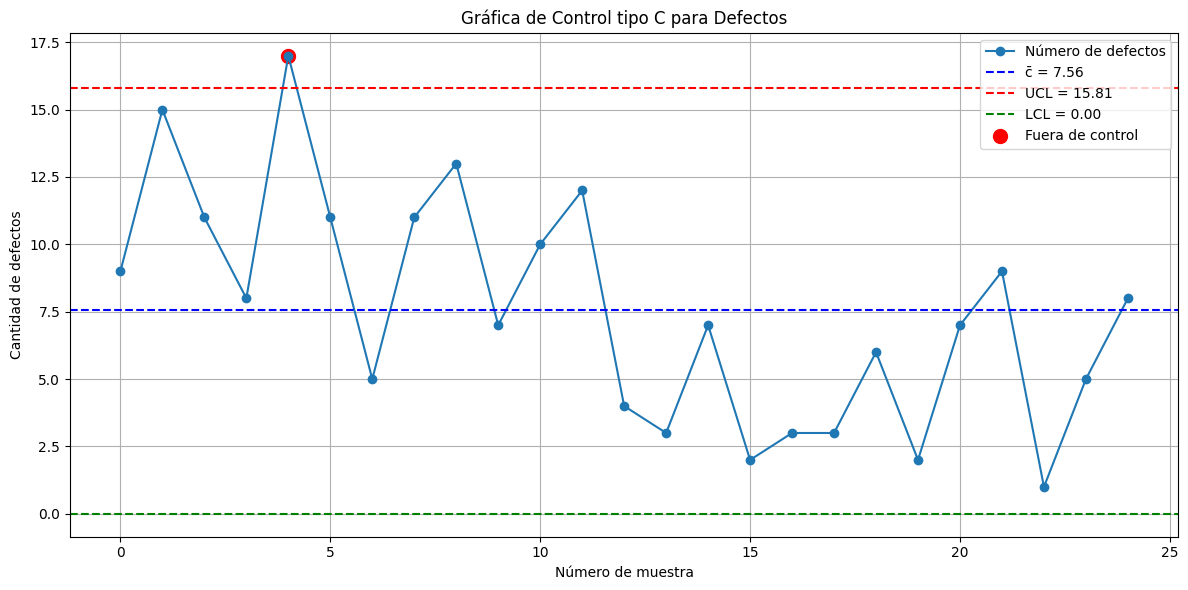

In [3]:
# === Gráfica de Control tipo C para Defectos ===
# Ejecutar en Google Colab

# Paso 1: Subir archivo CSV desde tu equipo
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

# Paso 2: Cargar el archivo (ajusta el nombre si es diferente)
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, encoding='utf-16', encoding_errors='ignore')

# Paso 3: Renombrar columna si es necesario
df.columns = ["Defectos"]

# Paso 4: Calcular promedio y límites de control
c_bar = df["Defectos"].mean()
UCL = c_bar + 3 * np.sqrt(c_bar)
LCL = max(0, c_bar - 3 * np.sqrt(c_bar))  # El límite inferior no puede ser negativo

# Paso 5: Identificar puntos fuera de control
out_of_control = df[(df["Defectos"] > UCL) | (df["Defectos"] < LCL)]

# Paso 6: Graficar
plt.figure(figsize=(12, 6))
plt.plot(df["Defectos"], marker='o', linestyle='-', label='Número de defectos')
plt.axhline(c_bar, color='blue', linestyle='--', label=f'c̄ = {c_bar:.2f}')
plt.axhline(UCL, color='red', linestyle='--', label=f'UCL = {UCL:.2f}')
plt.axhline(LCL, color='green', linestyle='--', label=f'LCL = {LCL:.2f}')
plt.scatter(out_of_control.index, out_of_control["Defectos"],
            color='red', s=100, label='Fuera de control')

plt.title("Gráfica de Control tipo C para Defectos")
plt.xlabel("Número de muestra")
plt.ylabel("Cantidad de defectos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()